In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult

In [2]:
ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params
import list_maps_plots
import circle_results_tools as crt

In [3]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization.wcsaxes.patches import SphericalCircle

c0 = SkyCoord.from_name("Tarantula")
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

## 1. Define analysis inputs


In [4]:
from pathlib import Path

name_file = "LVM-30Dor-6563"
run_labels = ["50pc", "100pc","150pc","200pc"]

run_info = {}

for run in run_labels:
    run_info[run] = {
        "name_file": name_file,
        "fits_dir": Path(f"fits_ready_{run}"),
        "catalog_path": Path(f"fits_ready_{run}/circle_catalog.csv"),
        "filelist_path": Path(f"fits_ready_{run}/filelist.txt"),
    }

run_info

{'50pc': {'name_file': 'LVM-30Dor-6563',
  'fits_dir': PosixPath('fits_ready_50pc'),
  'catalog_path': PosixPath('fits_ready_50pc/circle_catalog.csv'),
  'filelist_path': PosixPath('fits_ready_50pc/filelist.txt')},
 '100pc': {'name_file': 'LVM-30Dor-6563',
  'fits_dir': PosixPath('fits_ready_100pc'),
  'catalog_path': PosixPath('fits_ready_100pc/circle_catalog.csv'),
  'filelist_path': PosixPath('fits_ready_100pc/filelist.txt')},
 '150pc': {'name_file': 'LVM-30Dor-6563',
  'fits_dir': PosixPath('fits_ready_150pc'),
  'catalog_path': PosixPath('fits_ready_150pc/circle_catalog.csv'),
  'filelist_path': PosixPath('fits_ready_150pc/filelist.txt')},
 '200pc': {'name_file': 'LVM-30Dor-6563',
  'fits_dir': PosixPath('fits_ready_200pc'),
  'catalog_path': PosixPath('fits_ready_200pc/circle_catalog.csv'),
  'filelist_path': PosixPath('fits_ready_200pc/filelist.txt')}}

## 2. Load the list of exported circle names

In [5]:
names = {}

for run, info in run_info.items():
    with open(info["filelist_path"], "r", encoding="utf-8") as f:
        names[run] = [line.strip() for line in f if line.strip()]

names_50pc = names["50pc"]
names_100pc = names["100pc"]
names_150pc = names["150pc"]
names_200pc = names["200pc"]


names_50pc[:5], len(names_50pc)

(['LVM-30Dor-6563_A',
  'LVM-30Dor-6563_B1',
  'LVM-30Dor-6563_B2',
  'LVM-30Dor-6563_B3',
  'LVM-30Dor-6563_B4'],
 143)

## 3. Load all bundles

In [6]:
bundles = {}
dfs_obs = {}
dfs_fit = {}
meta_all = {}

for run, info in run_info.items():
    run_bundles = {}

    for name in names[run]:
        run_bundles[name] = results_comp.load_line_bundle(
            name,
            name,
            info["fits_dir"],
            read_header=True
        )

    bundles[run] = run_bundles
    dfs_obs[run]  = {name: bundle["obs"]  for name, bundle in run_bundles.items()}
    dfs_fit[run]  = {name: bundle["fit"]  for name, bundle in run_bundles.items()}
    meta_all[run] = {name: bundle["meta"] for name, bundle in run_bundles.items()}

## 4. Load the circle catalog

In [7]:
circles_df = {}
circles = {}

for run, info in run_info.items():
    circles_df[run], circles[run] = crt.load_circle_catalog(
        info["catalog_path"],
        info["name_file"]
    )

In [8]:
#circles_df['100pc']

## 5. Build the one-row-per-circle summary table

In [9]:
pc = {}
radius_arcsec = {}

for run in run_info:
    center_name = circles[run][0]["name"]
    pc[run] = meta_all[run][center_name]["PC"]
    radius_arcsec[run] = circles[run][0]["radius_arcsec"]

In [10]:
radius_arcsec['50pc']

206.5

In [11]:
results_df = {}

for run in run_info:
    results_df[run] = crt.build_circle_results_df(
        circles[run],
        dfs_fit[run],
        radius_arcsec=radius_arcsec[run],
        pc=pc[run],
        param_row=0,
    )

In [21]:

for run in run_info:
    r_arcsec = radius_arcsec[run]
    pc_run = pc[run]

    def ring_to_index(ring):
        ring = str(ring).upper()
        if len(ring) == 1 and ring.isalpha():
            return ord(ring) - ord("A")
        return np.nan

    results_df[run]["ring_index"] = results_df[run]["ring"].apply(ring_to_index)
    results_df[run]["radius_pc"] = 2.0 * results_df[run]["ring_index"] * r_arcsec * pc_run

In [22]:
results_df["50pc"].head()

,name,label,ring,angle_deg,ra_deg,dec_deg,radius_arcsec,sig2,r0,m,s0,noise,sig,radius_pc,ring_index
0,LVM-30Dor-6563_A,A,A,NaN,84.675000,-69.100000,206.5,221.443892,14.551935,2.000000,0.024241,28.321988,14.880991,0.000000,0
1,LVM-30Dor-6563_B1,B1,B,0.000000,84.675000,-68.985278,206.5,35.236001,7.647870,1.522903,0.363610,0.000005,5.935992,100.114025,1
2,LVM-30Dor-6563_B2,B2,B,51.428571,84.925606,-69.028289,206.5,20.474779,13.144678,1.390619,0.024241,0.012730,4.524907,100.114025,1
3,LVM-30Dor-6563_B3,B3,B,102.857143,84.988887,-69.125242,206.5,55.499334,14.947248,1.590132,0.024241,3.566438,7.449788,100.114025,1
4,LVM-30Dor-6563_B4,B4,B,154.285714,84.815193,-69.203304,206.5,261.279188,134.679010,1.058732,0.363610,0.020469,16.164133,100.114025,1


In [23]:
results_df["100pc"].head()

,name,label,ring,angle_deg,ra_deg,dec_deg,radius_arcsec,sig2,r0,m,s0,noise,sig,radius_pc,ring_index
0,LVM-30Dor-6563_A,A,A,NaN,84.675000,-69.100000,413.0,110.133960,14.829088,2.000000,0.024241,1.912547e+01,10.494473,0.00000,0
1,LVM-30Dor-6563_B1,B1,B,0.000000,84.675000,-68.870556,413.0,24.256030,20.182064,1.066867,0.363610,5.811127e-09,4.925041,200.22805,1
2,LVM-30Dor-6563_B2,B2,B,51.428571,85.174577,-68.956213,413.0,25.720978,25.831007,1.002494,0.363610,6.005429e-07,5.071585,200.22805,1
3,LVM-30Dor-6563_B3,B3,B,102.857143,85.303493,-69.149910,413.0,36.762483,19.810223,0.950363,0.363610,3.645102e-06,6.063207,200.22805,1
4,LVM-30Dor-6563_B4,B4,B,154.285714,84.956724,-69.306494,413.0,94.709611,17.254341,1.206104,0.363610,7.760268e-07,9.731886,200.22805,1


## 7. Ring-level statistics

In [24]:
stats_sig_ring = {}

for run in run_info:
    stats_sig_ring[run] = crt.compute_group_stats(
        results_df[run],
        "sig",
        group_col="ring",
        order=["A", "B", "C", "D", "E", "F", "G", "H"]
    )

In [25]:
stats_sig_ring['50pc']

,ring,count,mean,std,median
0,A,1,14.880991,NaN,14.880991
1,B,7,7.475190,4.027838,5.951143
2,C,13,6.580836,2.471385,6.009446
3,D,19,9.167508,6.807322,7.437245
4,E,23,8.872754,5.789997,6.664067
5,F,28,8.978102,4.915798,7.562499
6,G,34,8.745796,4.856873,7.394148
7,H,18,7.456491,5.000062,5.885466


In [26]:
stats_r0_ring = {}
stats_m_ring = {}

for run in run_info:
    stats_r0_ring[run] = crt.compute_group_stats(
        results_df[run], "r0", group_col="ring",
        order=["A", "B", "C", "D", "E", "F", "G", "H"]
    )

    stats_m_ring[run] = crt.compute_group_stats(
        results_df[run], "m", group_col="ring",
        order=["A", "B", "C", "D", "E", "F", "G", "H"]
    )

In [27]:
stats_m_ring['50pc']

,ring,count,mean,std,median
0,A,1,2.000000,NaN,2.000000
1,B,7,1.231867,0.355798,1.336090
2,C,13,1.170561,0.365064,1.117846
3,D,19,1.248301,0.275049,1.218867
4,E,23,1.356737,0.447053,1.269801
5,F,28,1.222806,0.430093,1.218642
6,G,34,1.380052,0.398314,1.392087
7,H,18,1.353085,0.433137,1.372708


## 8. Radius-in-pc version

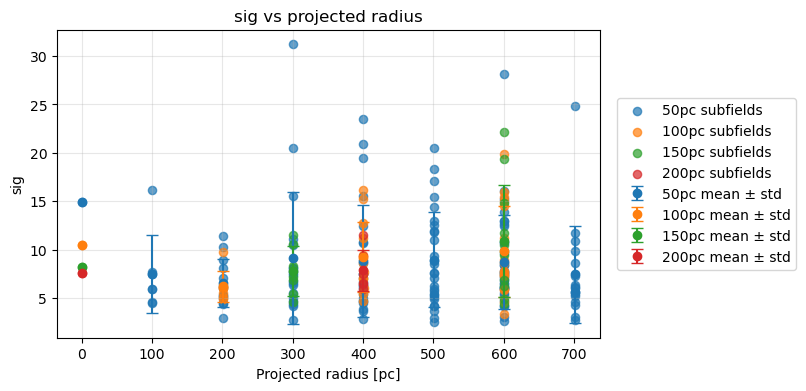

In [34]:
fig, ax, stats_sig = crt.plot_parameter_by_radius_multi(
    results_df,
    "sig",
    title="sig vs projected radius",
    ylabel="sig",
    jitter=0.05,
)

## 9. Repeat for `r0` and `m`

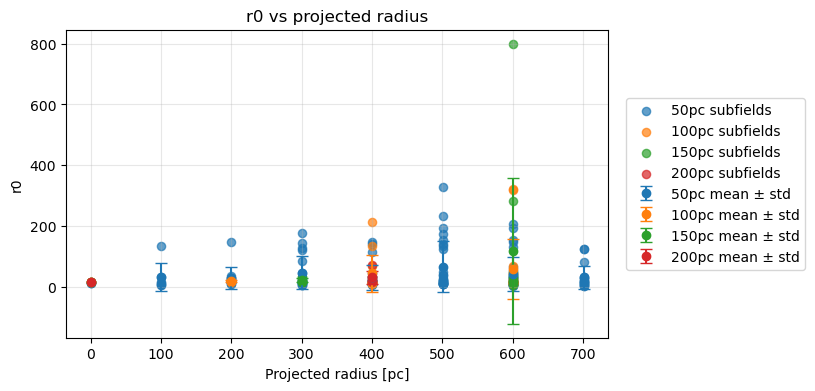

In [29]:
fig, ax, stats_r0 = crt.plot_parameter_by_radius_multi(
    results_df,
    "r0",
    title="r0 vs projected radius",
    ylabel="r0",
    jitter=0.02,
)

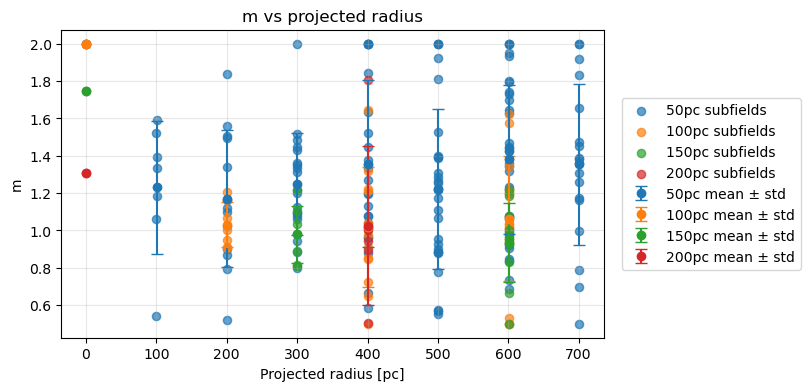

In [30]:
fig, ax, stats_m = crt.plot_parameter_by_radius_multi(
    results_df,
    "m",
    title="m vs projected radius",
    ylabel="m",
    jitter=0.02,
)